Dataset Preview:
      Region  Year  Violence_Victims  Complaints      Funding_EUR  \
0  Andalucía  2020              6813       30847  € 15,286,964.44   
1     Aragón  2020               725        3277   € 4,657,150.64   
2   Asturias  2020               622        2650   € 2,873,028.43   
3   Baleares  2020              1002        5880   € 4,142,542.43   
4   Canarias  2020              1734        8926   € 5,921,683.67   

   School_Leaving(%)  Unemployment_Rate(%)  
0               21.8                  22.3  
1               14.2                  11.7  
2                8.9                  14.1  
3               21.3                  16.1  
4               18.2                  22.6  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                95 non-null     object 
 1   Year                  9

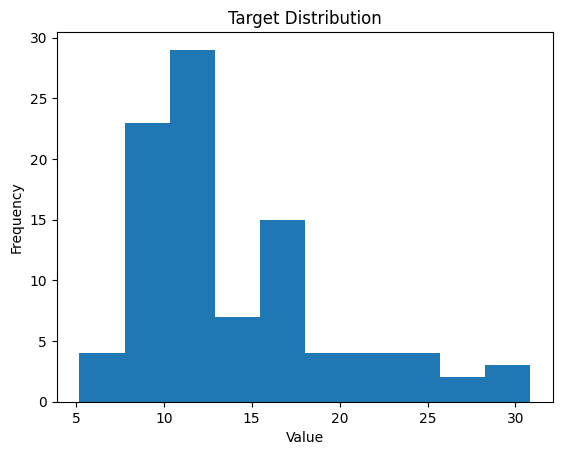

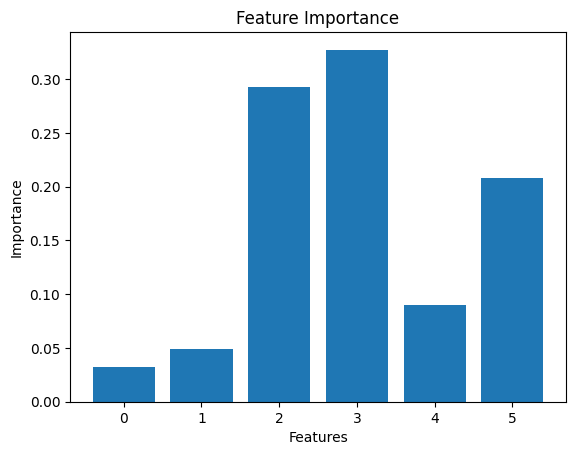

In [2]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor # Changed from RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score # Changed for regression metrics

# ==========================================
# LOAD DATASET
# ==========================================
data = pd.read_csv("Gender Violence Spain Dataset (2020-2024).csv")

print("Dataset Preview:")
print(data.head())

print("\nDataset Info:")
print(data.info())

# ==========================================
# DATA PREPROCESSING
# ==========================================

# Handle missing values
data = data.dropna()

# Encode categorical columns
label_encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = label_encoder.fit_transform(data[col])

# ==========================================
# FEATURE & TARGET SELECTION
# ==========================================

# Assume last column is target (change if needed)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# ==========================================
# FEATURE SCALING
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# MODEL TRAINING (Random Forest Regressor)
# ==========================================
model = RandomForestRegressor(n_estimators=100, random_state=42) # Changed to Regressor
model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================
print("\nMean Squared Error:", mean_squared_error(y_test, y_pred)) # Changed for regression
print("R2 Score:", r2_score(y_test, y_pred)) # Changed for regression

# Classification report and confusion matrix are not suitable for regression
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# ==========================================
# VISUALIZATION
# ==========================================

# Plot distribution of target
plt.figure()
plt.hist(y, bins=10)
plt.title("Target Distribution")
plt.xlabel("Value") # Changed label
plt.ylabel("Frequency")
plt.show()

# Feature importance
importances = model.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()